**Jupyter notebook** che usa **PyTorch** per addestrare una rete neurale artificiale per la classificazione di immagini di cifre scritte a mano.

**Fonte principale**: https://github.com/pytorch/examples/tree/main/mnist

**Autore**: [Brescia AI](https://brescia.ai)

Requirements: `torch`; `torchvision`; `matplotlib`.

## Funzioni

Codice da usare così com'è, non servono modifiche.

In [1]:
# MacOS bug
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR

In [3]:
class MNISTDataset():
    def __init__(self):
        self.training_data = datasets.MNIST('./data', train=True, download=True, transform=transforms.ToTensor())
        self.test_data = datasets.MNIST('./data', train=False, transform=transforms.ToTensor())
        

    def prepare_for_training(self, batch_size):
        def normalize(tensor):
            return (tensor - 0.1307) / 0.3081
        self.training_data.data = self.training_data.data.float() / 255.
        self.test_data.data = self.test_data.data.float() / 255.
        self.training_data.data = normalize(self.training_data.data)
        self.test_data.data = normalize(self.test_data.data)
        self.train_loader = torch.utils.data.DataLoader(self.training_data, batch_size=batch_size)
        self.test_loader = torch.utils.data.DataLoader(self.test_data, batch_size=1000)

    def visualize(self):
        fig, axes = plt.subplots(2, 2, figsize=(22, 14))
        
        for i in range(2):
            image, label = self.training_data[i]
            tensor = image.squeeze().numpy()
            
            # Left column: image
            axes[i, 0].imshow(tensor, cmap='gray')
            axes[i, 0].set_title(f'Label: {label}', fontsize=14)
            axes[i, 0].axis('off')
            
            # Right column: plain white background with numbers only
            axes[i, 1].set_xlim(-0.5, 27.5)
            axes[i, 1].set_ylim(27.5, -0.5)
            axes[i, 1].set_facecolor('white')
            for row in range(28):
                for col in range(28):
                    val = tensor[row, col]
                    axes[i, 1].text(col, row, f'{val:.1f}', ha='center', va='center',
                                    fontsize=6, color='black')
            axes[i, 1].set_title(f'Full 28×28 Tensor (Label: {label})', fontsize=14)
            axes[i, 1].axis('off')
        
        plt.tight_layout()
        plt.show()

In [4]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv = nn.Conv2d(1, 4, 3, 1)
        self.fc = nn.Linear(2704, 10)

    def forward(self, x):
        x = self.conv(x)
        x = F.relu(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        output = F.log_softmax(x, dim=1)
        return output

In [5]:
def train(model, device, train_loader, optimizer, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()
        # if batch_idx % 100 == 0:
        #     print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
        #         epoch, batch_idx * len(data), len(train_loader.dataset),
        #         100. * batch_idx / len(train_loader), loss.item()))


def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)

    print('Test set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))

def train_and_test(epochs, model, device, dataset, optimizer, scheduler):
    for epoch in range(1, epochs + 1):
        train(model, device, dataset.train_loader, optimizer, epoch)
        test(model, device, dataset.test_loader)
        scheduler.step()

## Dataset

Il dataset **MNIST** (Modified National Institute of Standards and Technology database) è una vasta base di dati di cifre scritte a mano comunemente impiegata come insieme di addestramento in vari sistemi per l'elaborazione delle immagini nel campo dell'apprendimento automatico.

In [6]:
dataset = MNISTDataset()

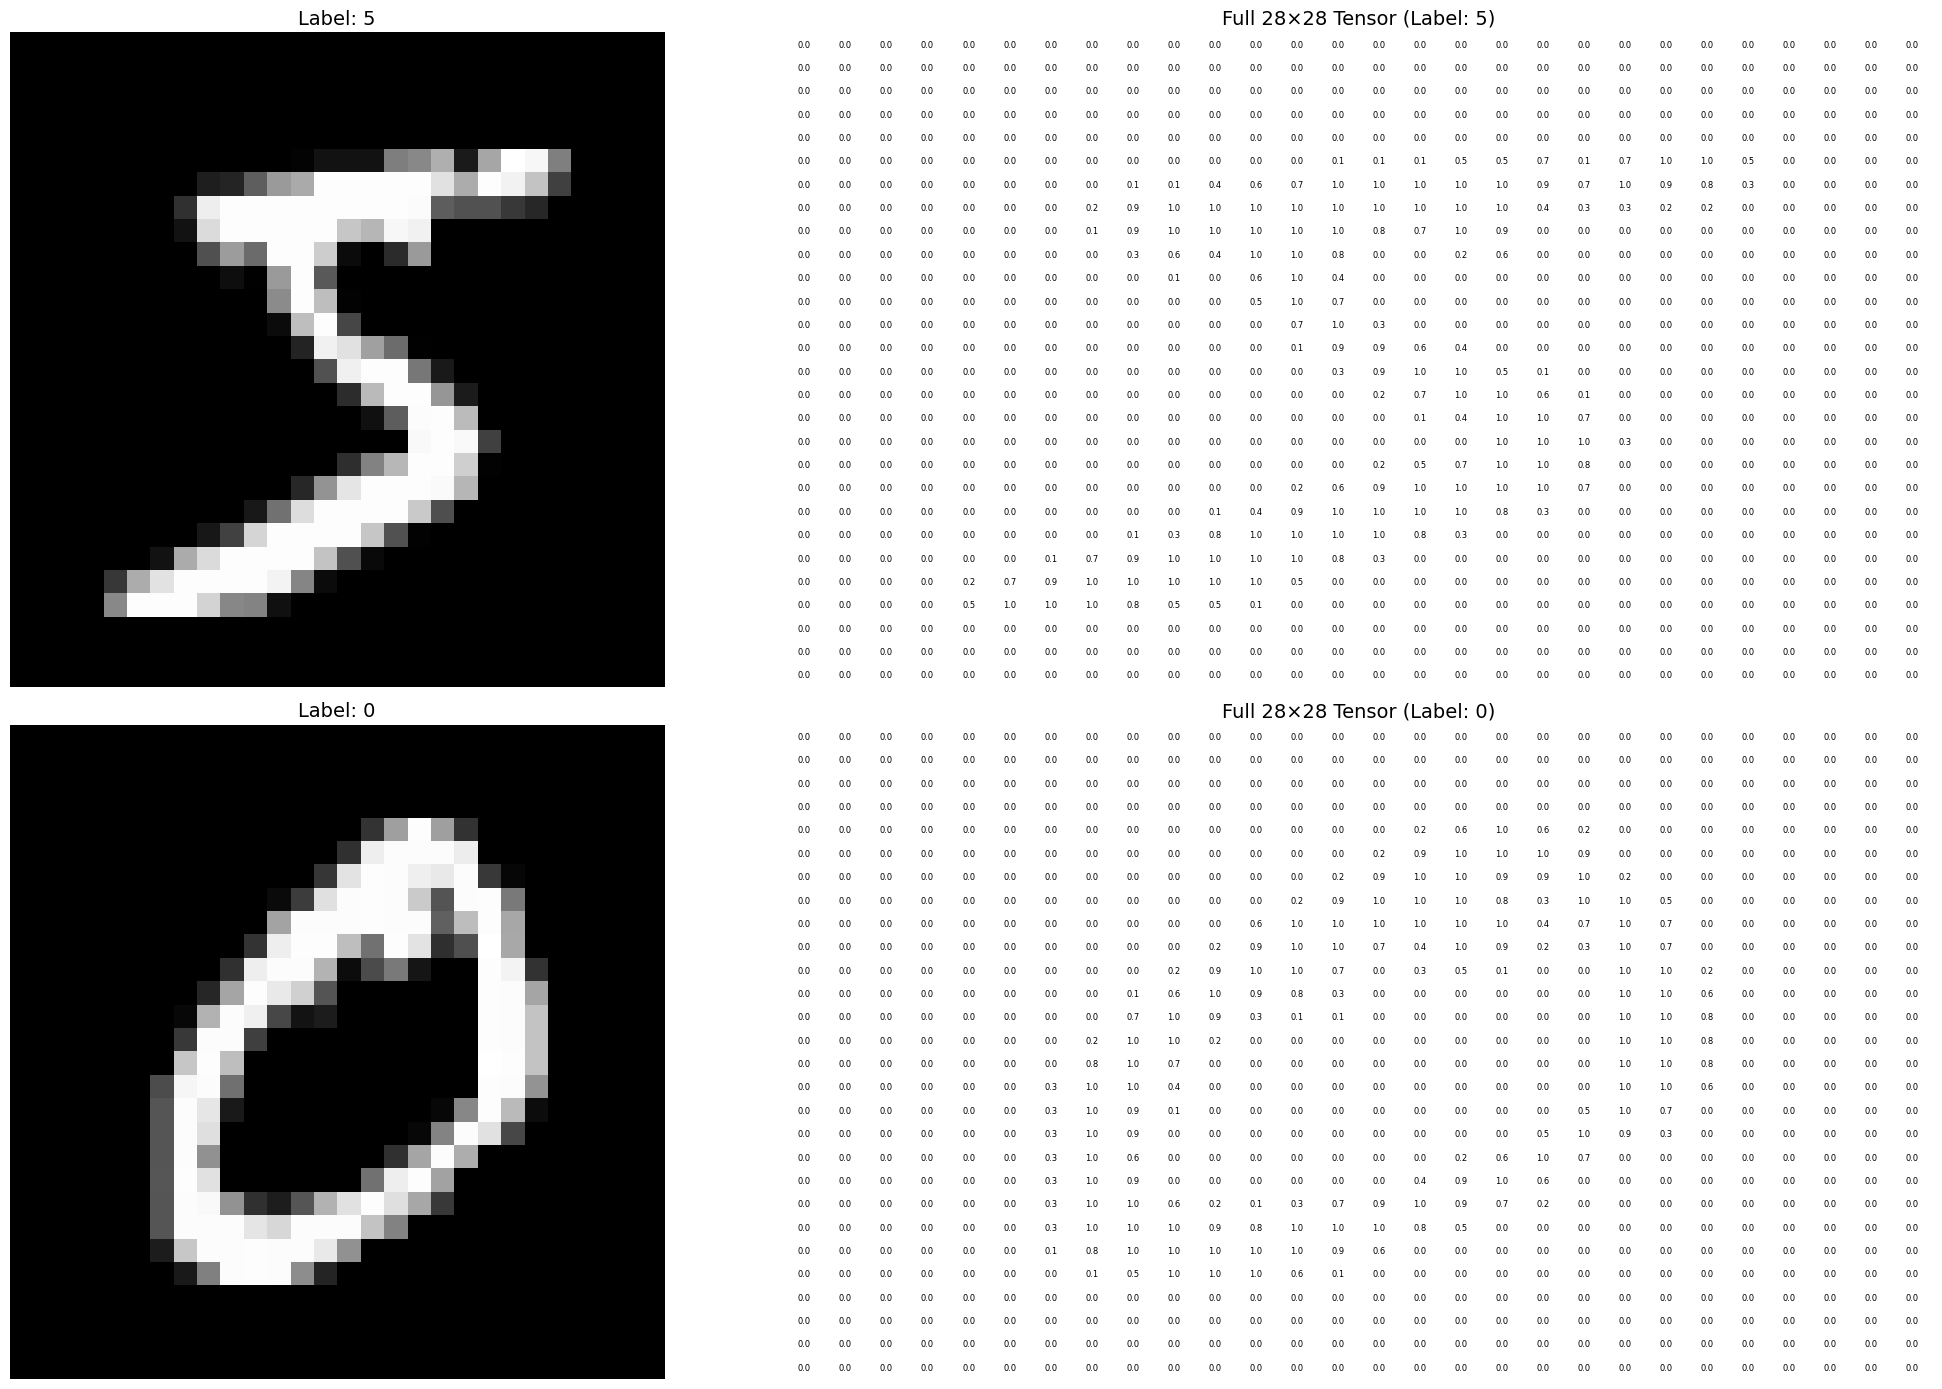

In [7]:
dataset.visualize()

Un media digitalizzato ha una rappresentazione numerica tanto più complessa quanto più era "carica di significato" la sua forma originale. Come vedete, già in questo semplce caso la matrice di ogni immagine è praticamente illeggibile da un essere umano.

## Modello

Useremo una **rete neurale convoluzionale** (CNN), oggi uno dei modelli di riferimento per il riconoscimento di oggetti in immagini. Come detto, non abbiamo purtroppo il tempo di spiegare i dettagli del suo funzionamento matematico, ma potete tranquillamente immaginarvela come una successione di operazioni pensate apposta per le matrici di numeri (cioè appunto per le immagini).

In [ ]:
device = torch.device("cpu")    # non useremo nessun acceleratore

In [ ]:
model = Net().to(device)

## Training

L'addestramento di un'IA dipende da alcune opzioni, i cosiddetti **iperparametri**, che l'utente deve scegliere prima di lanciare il processo. A noi interessano i seguenti:
- **batch_size**: da 1 a 64, ovvero il numero di immagini che il nostro modello vedrà contemporaneamente;
- **epochs**: da 1 in poi, ovvero il numero di volte che il nostro modello vedrà l'intero dataset di addestramento;
- **learning_rate**: da 0.1 a 1.0, ovvero la cautela con cui il nostro modello impara nuovi concetti dimenticando quelli precedenti;
- **gamma**: da 0.1 a 5.0, un parametro matematico oscuro.


In [ ]:
batch_size = 16
epochs = 10
learning_rate = 0.1
gamma = 0.1

In [ ]:
optimizer = optim.Adadelta(model.parameters(), lr=learning_rate)
scheduler = StepLR(optimizer, step_size=1, gamma=gamma)

Dividiamo il dataset in batch e cominciamo.

In [ ]:
dataset.prepare_for_training(batch_size)

In [ ]:
train_and_test(epochs, model, device, dataset, optimizer, scheduler)